# Model Training and Evaluation
## 12-Month Hospitalization Risk in Senior Living Populations

This notebook trains and evaluates Logistic Regression, Random Forest, and Gradient Boosting models with class balancing, performs threshold optimization on a held-out validation set, and reports final performance on the test set.

## Setup and Data Loading

In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, average_precision_score
from sklearn.metrics import roc_curve, confusion_matrix, precision_recall_curve, classification_report
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/hospitalization_risk_data.csv')

df['gender_encoded'] = LabelEncoder().fit_transform(df['gender'])

feature_cols = [col for col in df.columns if col not in ['DESYNPUF_ID', 'gender', 'hospitalization_risk']]

X = df[feature_cols]
y = df['hospitalization_risk']

## Train / Validation / Test Split

In [3]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Training set ({len(X_train)} samples):")
print(f"  No Hospitalization: {(y_train == 0).sum()} ({(y_train == 0).sum()/len(y_train)*100:.1f}%)")
print(f"  Hospitalization: {(y_train == 1).sum()} ({(y_train == 1).sum()/len(y_train)*100:.1f}%)")
print(f"\nValidation set ({len(X_val)} samples):")
print(f"  No Hospitalization: {(y_val == 0).sum()} ({(y_val == 0).sum()/len(y_val)*100:.1f}%)")
print(f"  Hospitalization: {(y_val == 1).sum()} ({(y_val == 1).sum()/len(y_val)*100:.1f}%)")
print(f"\nTest set ({len(X_test)} samples):")
print(f"  No Hospitalization: {(y_test == 0).sum()} ({(y_test == 0).sum()/len(y_test)*100:.1f}%)")
print(f"  Hospitalization: {(y_test == 1).sum()} ({(y_test == 1).sum()/len(y_test)*100:.1f}%)")

Training set (81445 samples):
  No Hospitalization: 68263 (83.8%)
  Hospitalization: 13182 (16.2%)

Validation set (11636 samples):
  No Hospitalization: 9753 (83.8%)
  Hospitalization: 1883 (16.2%)

Test set (23271 samples):
  No Hospitalization: 19505 (83.8%)
  Hospitalization: 3766 (16.2%)


## Cross-Validation

In [4]:
models_for_cv = {
    'Logistic Regression (Balanced)': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest (Balanced)': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Gradient Boosting (Balanced)': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
}

print("5-Fold Cross-Validation Results:")
print(f"{'Model':<35} {'Mean ROC-AUC':<15} {'Std Dev':<10}")
print("-" * 60)

cv_results = {}
for name, model in models_for_cv.items():
    if 'Logistic' in name:
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    else:
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    
    cv_results[name] = {
        'mean': cv_scores.mean(),
        'std': cv_scores.std(),
        'scores': cv_scores
    }
    
    print(f"{name:<35} {cv_scores.mean():<15.4f} {cv_scores.std():<10.4f}")

5-Fold Cross-Validation Results:
Model                               Mean ROC-AUC    Std Dev   
------------------------------------------------------------
Logistic Regression (Balanced)      0.7512          0.0060    
Random Forest (Balanced)            0.6738          0.0055    
Gradient Boosting (Balanced)        0.7544          0.0059    


## Hyperparameter Tuning

In [5]:
# Gradient Boosting grid search
print("Testing Gradient Boosting configurations...")
gb_param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.05, 0.1, 0.15],
    'max_depth': [3, 4, 5]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

gb_grid.fit(X_train, y_train)

print(f"\nBest Gradient Boosting parameters: {gb_grid.best_params_}")
print(f"Best CV ROC-AUC: {gb_grid.best_score_:.4f}")

Testing Gradient Boosting configurations...

Best Gradient Boosting parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}
Best CV ROC-AUC: 0.7543


In [6]:
# Random Forest configuration comparison
print("Testing Random Forest configurations...")
rf_configs = {
    'RF Default (n=100)': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'RF Tuned (n=200, depth=10)': RandomForestClassifier(
        n_estimators=200, 
        max_depth=10, 
        min_samples_split=10,
        min_samples_leaf=5, 
        class_weight='balanced', 
        random_state=42,
        n_jobs=-1
    )
}

rf_cv_results = {}
for config_name, rf_model in rf_configs.items():
    rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1)
    rf_cv_results[config_name] = rf_cv_scores.mean()
    print(f"  {config_name}: CV ROC-AUC = {rf_cv_scores.mean():.4f}")

best_rf_config = max(rf_cv_results.keys(), key=lambda x: rf_cv_results[x])

print("\nRe-running CV with tuned Random Forest...")
tuned_rf = rf_configs[best_rf_config]
tuned_rf_cv = cross_val_score(tuned_rf, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
cv_results['Random Forest (Balanced)'] = {
    'mean': tuned_rf_cv.mean(),
    'std': tuned_rf_cv.std(),
    'scores': tuned_rf_cv
}
print(f"Tuned RF CV ROC-AUC: {tuned_rf_cv.mean():.4f} (+/- {tuned_rf_cv.std():.4f})")
print(f"Best Random Forest configuration: {best_rf_config}")

Testing Random Forest configurations...
  RF Default (n=100): CV ROC-AUC = 0.6733
  RF Tuned (n=200, depth=10): CV ROC-AUC = 0.7512

Re-running CV with tuned Random Forest...
Tuned RF CV ROC-AUC: 0.7518 (+/- 0.0061)
Best Random Forest configuration: RF Tuned (n=200, depth=10)


## Model Training and Validation

In [7]:
models_balanced = {
    'Logistic Regression (Balanced)': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest (Balanced)': rf_configs[best_rf_config],
    'Gradient Boosting (Balanced)': gb_grid.best_estimator_
}

results_balanced = {}

for name, model in models_balanced.items():
    print(f"Training {name}...")
    
    if 'Logistic' in name:
        model.fit(X_train_scaled, y_train)
        y_pred_proba = model.predict_proba(X_val_scaled)[:, 1]
        y_pred = model.predict(X_val_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred_proba = model.predict_proba(X_val)[:, 1]
        y_pred = model.predict(X_val)
    
    roc_auc = roc_auc_score(y_val, y_pred_proba)
    pr_auc = average_precision_score(y_val, y_pred_proba)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    
    results_balanced[name] = {
        'model': model,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'y_pred_proba': y_pred_proba,
        'y_pred': y_pred
    }
    
    print(f"  ROC-AUC: {roc_auc:.4f}  PR-AUC: {pr_auc:.4f}  "
          f"Precision: {precision:.4f}  Recall: {recall:.4f}  F1: {f1:.4f}")

best_balanced_name = max(results_balanced.keys(), key=lambda x: results_balanced[x]['roc_auc'])
print(f"\nBest balanced model by ROC-AUC: {best_balanced_name}")

Training Logistic Regression (Balanced)...
  ROC-AUC: 0.7437  PR-AUC: 0.3313  Precision: 0.2758  Recall: 0.6920  F1: 0.3944
Training Random Forest (Balanced)...
  ROC-AUC: 0.7493  PR-AUC: 0.3411  Precision: 0.2651  Recall: 0.7679  F1: 0.3942
Training Gradient Boosting (Balanced)...
  ROC-AUC: 0.7504  PR-AUC: 0.3434  Precision: 0.5130  Recall: 0.0313  F1: 0.0591

Best balanced model by ROC-AUC: Gradient Boosting (Balanced)


## Threshold Optimization (Validation Set)

In [8]:
best_model = results_balanced[best_balanced_name]['model']
y_pred_proba_val = results_balanced[best_balanced_name]['y_pred_proba']

thresholds_to_test = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
threshold_results = []

print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1 Score':<12} {'Flagged %':<12}")
print("-" * 60)

for thresh in thresholds_to_test:
    y_pred_thresh = (y_pred_proba_val >= thresh).astype(int)
    
    precision = precision_score(y_val, y_pred_thresh, zero_division=0)
    recall = recall_score(y_val, y_pred_thresh)
    f1 = f1_score(y_val, y_pred_thresh, zero_division=0)
    flagged_pct = y_pred_thresh.sum() / len(y_pred_thresh) * 100
    
    threshold_results.append({
        'threshold': thresh,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'flagged_pct': flagged_pct
    })
    
    print(f"{thresh:<12.2f} {precision:<12.4f} {recall:<12.4f} {f1:<12.4f} {flagged_pct:<12.1f}%")

threshold_df = pd.DataFrame(threshold_results)
best_f1_idx = threshold_df['f1_score'].idxmax()
recommended_threshold = threshold_df.loc[best_f1_idx, 'threshold']

print(f"\nRecommended threshold (best F1): {recommended_threshold:.2f} "
      f"(F1={threshold_df.loc[best_f1_idx, 'f1_score']:.4f}, "
      f"Recall={threshold_df.loc[best_f1_idx, 'recall']:.4f})")

Threshold    Precision    Recall       F1 Score     Flagged %   
------------------------------------------------------------
0.10         0.2331       0.9352       0.3731       64.9        %
0.15         0.2546       0.8359       0.3903       53.1        %
0.20         0.2840       0.6660       0.3982       37.9        %
0.25         0.3257       0.4849       0.3897       24.1        %
0.30         0.3804       0.3319       0.3545       14.1        %
0.35         0.4281       0.2023       0.2748       7.6         %
0.40         0.4600       0.1190       0.1890       4.2         %
0.45         0.4656       0.0611       0.1080       2.1         %
0.50         0.5130       0.0313       0.0591       1.0         %

Recommended threshold (best F1): 0.20 (F1=0.3982, Recall=0.6660)


## Final Evaluation on Test Set

In [9]:
if 'Logistic' in best_balanced_name:
    y_pred_proba_test = best_model.predict_proba(X_test_scaled)[:, 1]
else:
    y_pred_proba_test = best_model.predict_proba(X_test)[:, 1]

y_pred_test = (y_pred_proba_test >= recommended_threshold).astype(int)

test_roc_auc = roc_auc_score(y_test, y_pred_proba_test)
test_pr_auc = average_precision_score(y_test, y_pred_proba_test)
test_precision = precision_score(y_test, y_pred_test)
test_recall = recall_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test)

print(f"Final Test Set Performance:")
print(f"  Model: {best_balanced_name}")
print(f"  Threshold: {recommended_threshold:.2f}")
print(f"  ROC-AUC: {test_roc_auc:.4f}")
print(f"  PR-AUC: {test_pr_auc:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1 Score: {test_f1:.4f}")
print(f"  Patients flagged: {y_pred_test.sum()} ({y_pred_test.sum()/len(y_pred_test)*100:.1f}%)")

Final Test Set Performance:
  Model: Gradient Boosting (Balanced)
  Threshold: 0.20
  ROC-AUC: 0.7558
  PR-AUC: 0.3440
  Precision: 0.2943
  Recall: 0.6710
  F1 Score: 0.4091
  Patients flagged: 8587 (36.9%)


## Visualizations

### ROC and Precision-Recall Curves

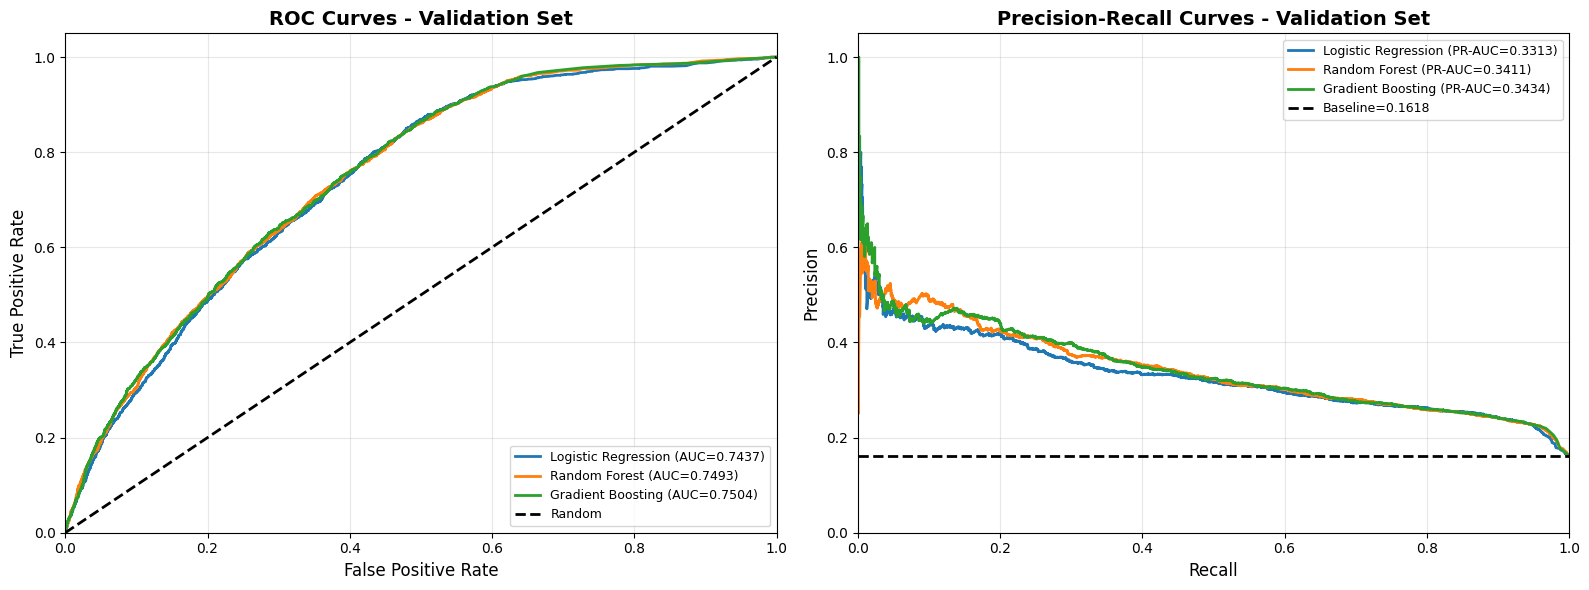

In [10]:
import os
os.makedirs('../figures', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for name in results_balanced.keys():
    fpr, tpr, _ = roc_curve(y_val, results_balanced[name]['y_pred_proba'])
    auc = results_balanced[name]['roc_auc']
    ax.plot(fpr, tpr, label=f'{name.split("(")[0].strip()} (AUC={auc:.4f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=2)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - Validation Set', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
for name in results_balanced.keys():
    precision_vals, recall_vals, _ = precision_recall_curve(y_val, results_balanced[name]['y_pred_proba'])
    pr_auc = results_balanced[name]['pr_auc']
    ax.plot(recall_vals, precision_vals, label=f'{name.split("(")[0].strip()} (PR-AUC={pr_auc:.4f})', linewidth=2)

baseline = y_val.sum() / len(y_val)
ax.axhline(y=baseline, color='k', linestyle='--', label=f'Baseline={baseline:.4f}', linewidth=2)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves - Validation Set', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/roc_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()

### Threshold Analysis

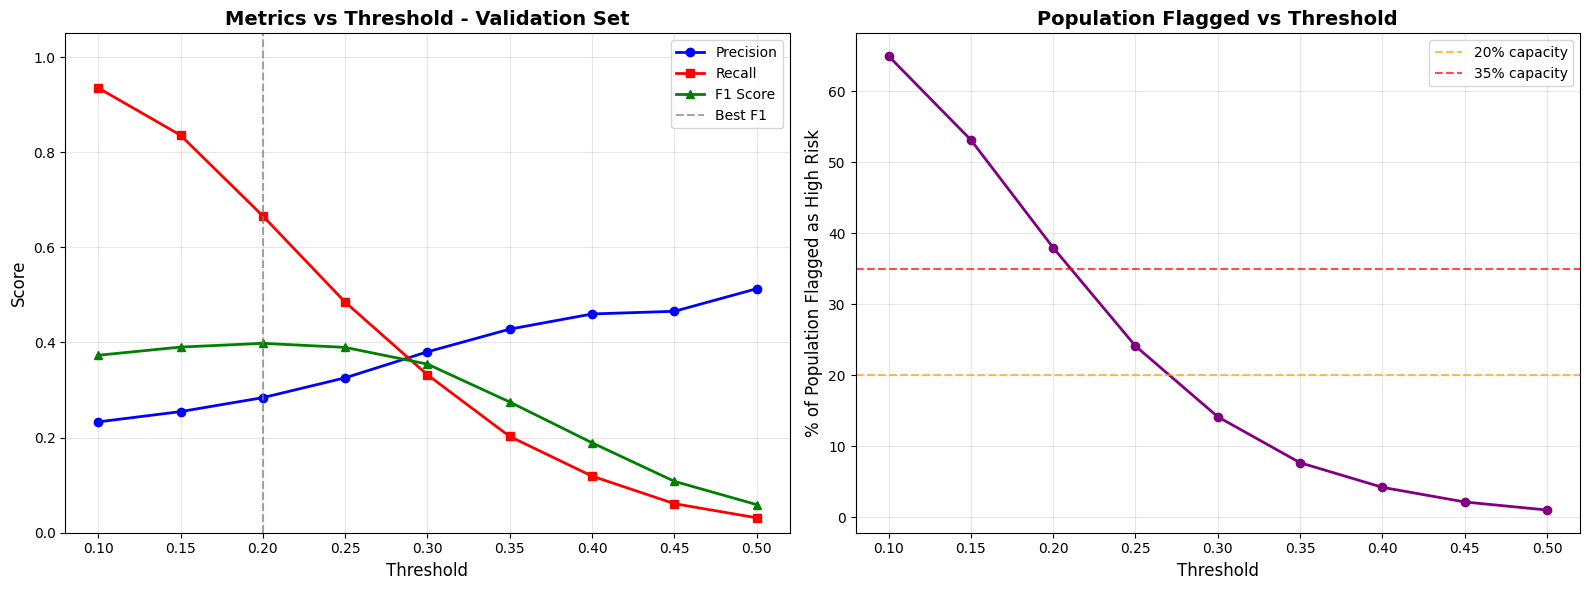

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.plot(threshold_df['threshold'], threshold_df['precision'], 'b-o', label='Precision', linewidth=2)
ax.plot(threshold_df['threshold'], threshold_df['recall'], 'r-s', label='Recall', linewidth=2)
ax.plot(threshold_df['threshold'], threshold_df['f1_score'], 'g-^', label='F1 Score', linewidth=2)
ax.axvline(x=threshold_df.loc[best_f1_idx, 'threshold'], color='gray', linestyle='--', alpha=0.7, label='Best F1')
ax.set_xlabel('Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'Metrics vs Threshold - Validation Set', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

ax = axes[1]
ax.plot(threshold_df['threshold'], threshold_df['flagged_pct'], 'purple', linewidth=2, marker='o')
ax.set_xlabel('Threshold', fontsize=12)
ax.set_ylabel('% of Population Flagged as High Risk', fontsize=12)
ax.set_title('Population Flagged vs Threshold', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=20, color='orange', linestyle='--', alpha=0.7, label='20% capacity')
ax.axhline(y=35, color='red', linestyle='--', alpha=0.7, label='35% capacity')
ax.legend(loc='best', fontsize=10)

plt.tight_layout()
plt.savefig('../figures/threshold_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

### Confusion Matrices

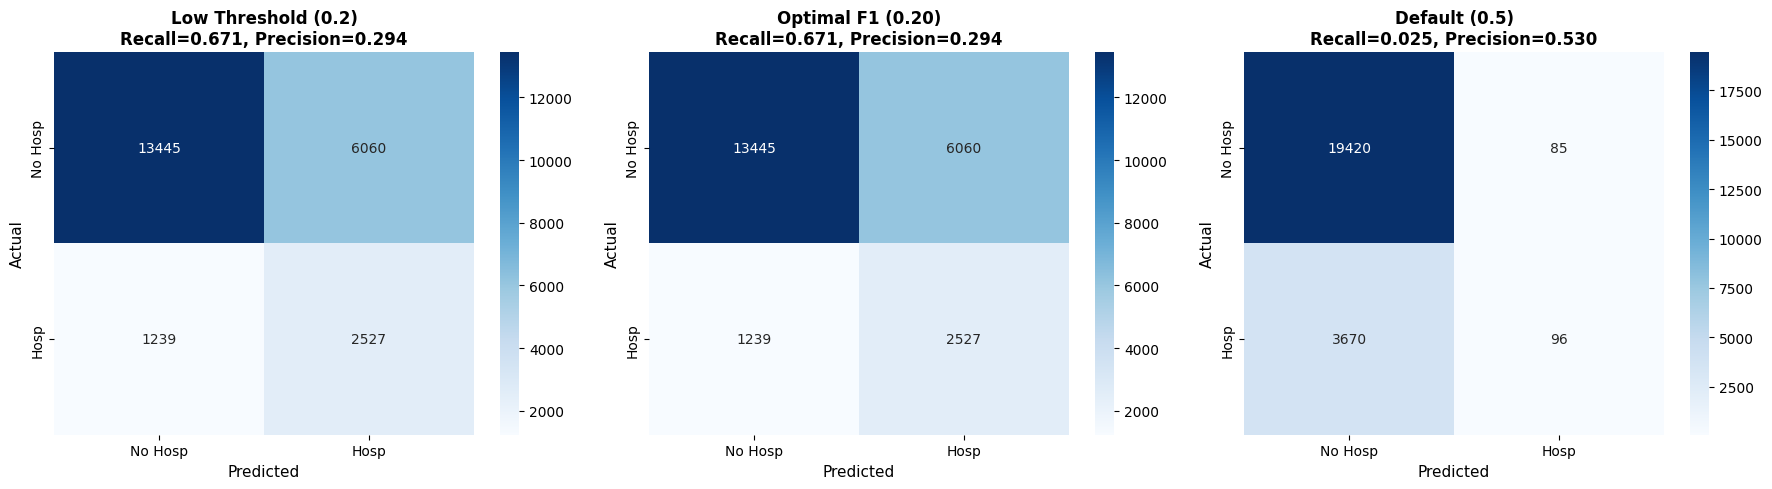

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

thresholds_to_show = [0.2, threshold_df.loc[best_f1_idx, 'threshold'], 0.5]
titles = ['Low Threshold (0.2)', f'Optimal F1 ({threshold_df.loc[best_f1_idx, "threshold"]:.2f})', 'Default (0.5)']

for idx, (thresh, title) in enumerate(zip(thresholds_to_show, titles)):
    y_pred_cm = (y_pred_proba_test >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_cm)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=axes[idx],
                xticklabels=['No Hosp', 'Hosp'],
                yticklabels=['No Hosp', 'Hosp'])
    
    recall_val = recall_score(y_test, y_pred_cm)
    precision_val = precision_score(y_test, y_pred_cm, zero_division=0)
    
    axes[idx].set_xlabel('Predicted', fontsize=11)
    axes[idx].set_ylabel('Actual', fontsize=11)
    axes[idx].set_title(f'{title}\nRecall={recall_val:.3f}, Precision={precision_val:.3f}', 
                        fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

### Feature Importance

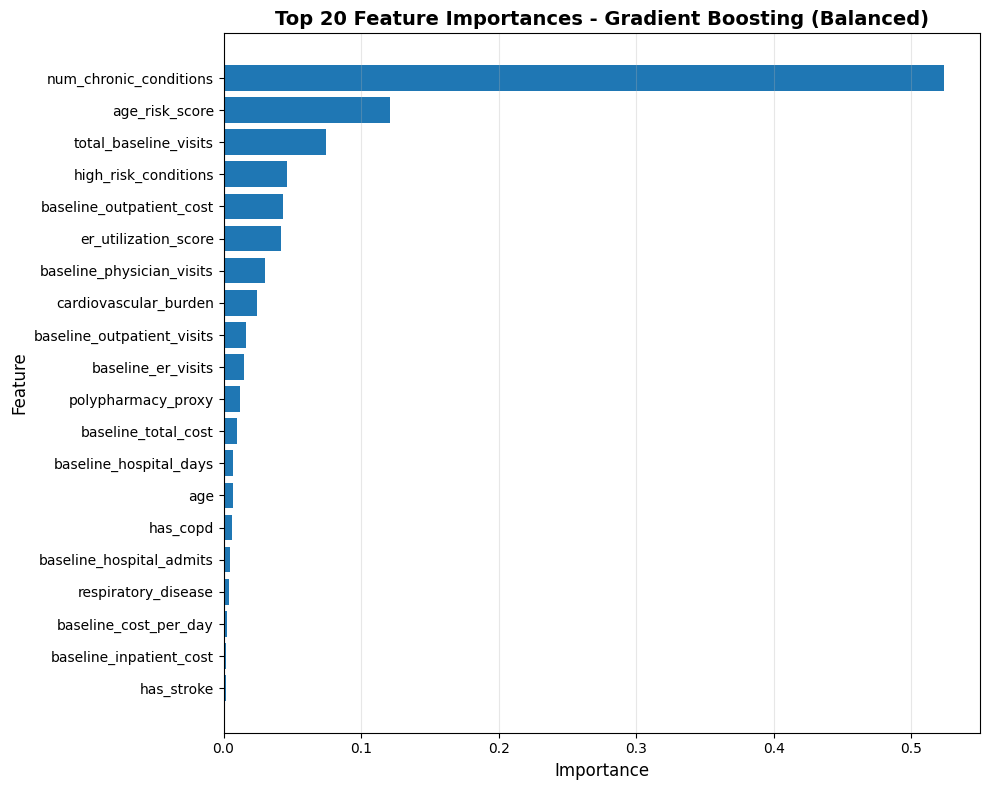

In [13]:
if best_balanced_name in ['Random Forest (Balanced)', 'Gradient Boosting (Balanced)']:
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False).head(20)
    
    plt.figure(figsize=(10, 8))
    plt.barh(range(len(feature_importance)), feature_importance['importance'])
    plt.yticks(range(len(feature_importance)), feature_importance['feature'])
    plt.xlabel('Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.title(f'Top 20 Feature Importances - {best_balanced_name}', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig('../figures/feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

## Summary

In [14]:
print("Model Development Summary")
print("=" * 60)

print(f"\nData split: 70% train, 10% validation, 20% test")
print(f"Training samples: {len(X_train):,}")
print(f"Validation samples: {len(X_val):,}")
print(f"Test samples: {len(X_test):,}")

print(f"\nCross-Validation Performance (Training Set):")
for name in cv_results.keys():
    cv_mean = cv_results[name]['mean']
    cv_std = cv_results[name]['std']
    val_auc = results_balanced[name]['roc_auc']
    print(f"  {name}")
    print(f"    CV ROC-AUC: {cv_mean:.4f} (+/- {cv_std:.4f})")
    print(f"    Validation ROC-AUC: {val_auc:.4f}")

print(f"\nBest Model Configuration:")
if 'Gradient Boosting' in best_balanced_name:
    print(f"  Model: Gradient Boosting Classifier")
    print(f"  Parameters: {gb_grid.best_params_}")
elif 'Random Forest' in best_balanced_name:
    print(f"  Model: Random Forest Classifier")
    print(f"  Configuration: {best_rf_config}")
else:
    print(f"  Model: Logistic Regression")
    print(f"  Parameters: max_iter=1000, class_weight='balanced'")

print(f"\nFinal Test Set Performance:")
print(f"  ROC-AUC: {test_roc_auc:.4f}")
print(f"  PR-AUC: {test_pr_auc:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1 Score: {test_f1:.4f}")
print(f"  % Population Flagged: {y_pred_test.sum()/len(y_pred_test)*100:.1f}%")

Model Development Summary

Data split: 70% train, 10% validation, 20% test
Training samples: 81,445
Validation samples: 11,636
Test samples: 23,271

Cross-Validation Performance (Training Set):
  Logistic Regression (Balanced)
    CV ROC-AUC: 0.7512 (+/- 0.0060)
    Validation ROC-AUC: 0.7437
  Random Forest (Balanced)
    CV ROC-AUC: 0.7518 (+/- 0.0061)
    Validation ROC-AUC: 0.7493
  Gradient Boosting (Balanced)
    CV ROC-AUC: 0.7544 (+/- 0.0059)
    Validation ROC-AUC: 0.7504

Best Model Configuration:
  Model: Gradient Boosting Classifier
  Parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}

Final Test Set Performance:
  ROC-AUC: 0.7558
  PR-AUC: 0.3440
  Precision: 0.2943
  Recall: 0.6710
  F1 Score: 0.4091
  % Population Flagged: 36.9%


## Save Model

In [15]:
model_package = {
    'model': best_model,
    'scaler': scaler if 'Logistic' in best_balanced_name else None,
    'feature_columns': feature_cols,
    'model_name': best_balanced_name,
    'recommended_threshold': recommended_threshold,
    'performance': {
        'test_roc_auc': test_roc_auc,
        'test_pr_auc': test_pr_auc,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_f1_score': test_f1,
        'cv_mean': cv_results[best_balanced_name]['mean'],
        'cv_std': cv_results[best_balanced_name]['std']
    }
}

model_filename = "../models/hospitalization_risk_model.pkl"

with open(model_filename, 'wb') as f:
    pickle.dump(model_package, f)

print(f"Model saved to: {model_filename}")

Model saved to: ../models/hospitalization_risk_model.pkl
